# Practical Statistics for Data Scientists (Python)
# Chapter 4. Regression and Prediction
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

**Reproduksi dan pembahasan:** Nanda Pratama ITM · NIM 101032330212 · TK 47 01.

Kode diadaptasi dari repositori resmi Peter Bruce, Andrew Bruce, dan Peter Gedeck (GPL-3.0); bukan klaim kode orisinal mahasiswa. Penjelasan Indonesia dan eksperimen tambahan disusun dengan bantuan AI. Sumber serta koreksi tercatat pada README dan docs/PERUBAHAN.md.

## Petunjuk penggunaan dan sumber

Baca teori berikut, kemudian jalankan sel kode berurutan dari atas ke bawah. Bagian **Reproduksi kode buku** mempertahankan semua sel Python nonkosong sumber resmi dengan koreksi yang dicatat. Bagian **Eksperimen tambahan** adalah pengembangan edukatif. Notebook gabungan ini telah dijalankan berurutan pada kernel baru, termasuk eksperimen tambahan.

Referensi utama: Bruce, Bruce, & Gedeck (2020), *Practical Statistics for Data Scientists*, edisi ke-2. [Kode resmi](https://github.com/gedeck/practical-statistics-for-data-scientists), commit `8a6d3bb6468e979c861d4b37215e1413702dfdfa`. Lihat [catatan perubahan](../docs/PERUBAHAN.md).

# Ringkasan dan pendalaman teori Bab 4

Regresi memodelkan respons numerik dari satu atau beberapa prediktor. Contoh fungsi paru dan harga rumah menunjukkan estimasi koefisien, pemeriksaan residual, pembandingan model, dan perluasan nonlinear melalui polinomial, spline, serta GAM.


## Regresi sederhana dan least squares
Model $Y=\beta_0+\beta_1X+\epsilon$ memisahkan hubungan rata-rata dan variasi yang tidak dijelaskan. Fitted value $\hat y_i=b_0+b_1x_i$; residual $e_i=y_i-\hat y_i$. Least squares meminimalkan $\sum_ie_i^2$. Koefisien Exposure menunjukkan perubahan rata-rata PEFR per satuan Exposure dalam model, bukan otomatis efek kausal. Intercept X=0 perlu konteks bila berada di luar kondisi yang relevan.


## Regresi berganda dan penilaian
Model $\hat y=b_0+\sum_jb_jx_j$ membaca koefisien sebagai perubahan prediksi ketika satu prediktor berubah dan yang lain tetap. RMSE $=\sqrt{\sum_i(y_i-\hat y_i)^2/n}$ bersatuan target dan sensitif pada error besar. $R^2=1-SSE/SST$ membandingkan error terhadap baseline mean. Di data uji, R-squared dapat negatif. Adjusted R-squared memperhitungkan jumlah prediktor tetapi tidak menggantikan evaluasi data baru.

Statsmodels menampilkan koefisien, standard error, interval, dan uji di bawah asumsi model. OLS berbasis matriks tidak otomatis menambah intercept. Skor dari data fit pada reproduksi adalah ukuran training; tambahan notebook menyediakan holdout dan CV yang dipisahkan. Tujuan prediksi menekankan akurasi data baru, sedangkan explanation menekankan interpretasi parameter; keduanya tetap memerlukan asumsi dan data yang sesuai.


## Cross-validation, seleksi model, dan AIC
K-fold melatih di k-1 fold dan memvalidasi pada sisanya. Preprocessing yang mempelajari parameter harus berada di dalam fold. Data temporal membutuhkan split sesuai waktu. AIC $=2k-2\log\hat L$ memberi penalti kompleksitas; lebih kecil lebih baik pada model dengan data/likelihood yang sebanding.

Stepwise menambah/membuang fitur berdasarkan kriteria. Pencarian lokal ini dapat tidak stabil pada fitur berkorelasi; p-value pascaseleksi tidak boleh diperlakukan seperti hipotesis yang ditentukan sebelumnya. Ridge/Lasso mengendalikan kompleksitas lewat penalti. Lasso menambah $\lambda\sum_j|b_j|$ dan dapat membuat koefisien nol. Standardisasi penting karena penalti dipengaruhi satuan fitur. Materi Lasso sumber ditandai sebagai tambahan di luar isi utama buku.


## Regresi berbobot
Weighted least squares meminimalkan $\sum_iw_ie_i^2$. Bobot inverse variance cocok ketika varians error diketahui/diestimasi memadai. Pada contoh, bobot tahun membuat transaksi lebih baru berpengaruh lebih besar; itu pilihan relevansi waktu, bukan otomatis koreksi heteroskedastisitas. Bandingkan perubahan koefisien dan error per tahun.


## Ekstrapolasi dan interval
Prediksi jauh di luar rentang training adalah ekstrapolasi, yang berisiko salah meski skor training tinggi. Confidence interval menggambarkan ketidakpastian mean respons pada x tertentu; prediction interval menambahkan variasi individual dan biasanya lebih lebar. Ketergantungan residual atau heteroskedastisitas yang diabaikan dapat membuat interval terlalu sempit.


## Faktor, banyak kategori, dan ordinal
Dengan intercept, k kategori nominal lazim dikodekan dengan k-1 dummy. Kategori yang dihilangkan menjadi acuan; koefisien dummy membandingkan dengan acuan pada fitur lain yang tetap. Semua dummy plus intercept menghasilkan ketergantungan linear sempurna. Kode ordinal 1,2,3 mengasumsikan jarak dan efek linear yang belum tentu tepat.

Sumber mengelompokkan kode pos berdasarkan median residual seluruh data. Ini dipertahankan untuk reproduksi deskriptif. **ZipGroup seperti ini berpotensi bocor untuk evaluasi prediksi** karena sudah melihat target. Untuk generalisasi, kelompok harus dipelajari hanya dari training/fold. Tambahan holdout memakai fitur numerik asli sehingga tidak memakai kelompok berbasis residual tersebut.


## Multikolinearitas, confounding, dan interaksi
Fitur berkorelasi kuat membuat koefisien sensitif dan standard error besar, meski prediksi gabungan masih baik. Tanda koefisien Bedrooms harus dibaca setelah mengondisikan luas dan kualitas rumah. Confounding terjadi ketika variabel terkait prediktor sekaligus respons tidak dimasukkan, sehingga asosiasi berubah setelah penyesuaian. Penyesuaian statistik tidak otomatis membuktikan kausalitas.

Interaksi $b_3X_1X_2$ membuat slope X1 menjadi $b_1+b_3X_2$. Formula `SqFtTotLiving*ZipGroup` memasukkan main effects dan interaksi, sehingga slope luas dapat berbeda antarwilayah. Interpretasi main effect harus menyebut nilai acuan variabel yang berinteraksi.


## Diagnostik
Outlier respons memiliki residual besar; leverage tinggi berarti fitur jauh dari pusat data. Cook's distance menggabungkan residual dan leverage untuk menilai perubahan fit bila observasi dihilangkan. Observasi berpengaruh perlu ditelusuri, bukan dibuang otomatis untuk meningkatkan skor.

Pola kipas residual terhadap fitted mengindikasikan heteroskedastisitas. Normalitas residual berkaitan terutama dengan inferensi kecil-sampel; target mentah tidak harus normal agar regresi dapat dipasang. Error berkorelasi, misalnya properti berdekatan atau serial, membuat standard error biasa tidak tepat. Pola melengkung menunjukkan bentuk mean belum cukup linear. Partial residual plot membantu mengisolasi pola suatu prediktor setelah fitur lain diperhitungkan, tetapi tetap dipengaruhi spesifikasi model.


## Polinomial, spline, dan GAM
Polinomial menambah pangkat X; nonlinear terhadap X tetapi linear terhadap koefisien. Derajat tinggi dapat berosilasi dan buruk untuk ekstrapolasi. Spline menggabungkan potongan polinomial dengan syarat kehalusan pada knot; jumlah knot dan derajat bebas mengatur kompleksitas lokal.

GAM memakai $g(E[Y|X])=\beta_0+\sum_j f_j(X_j)$. Link identitas cocok untuk respons Gaussian; keluarga lain memerlukan link sesuai. Komponen halus memudahkan membaca pola nonlinear, namun additivity membatasi interaksi kecuali ditambahkan. Penalti kehalusan perlu dituning. Inferensi p-value GAM setelah tuning perlu memperhatikan keterbatasan paket, termasuk peringatan yang dicetak pada output.


## Interpretasi dan kesimpulan
Bandingkan slope fungsi paru, model rumah berganda, serta perubahan setelah faktor wilayah dan interaksi. Periksa residual dan observasi berpengaruh. Pada evaluasi tambahan, bandingkan RMSE terhadap baseline mean, skor CV training, dan lebar confidence/prediction interval. Regresi memperkenalkan loss, regularisasi, dan generalisasi yang juga mendasari deep learning.


# Reproduksi kode buku
Sel berikut diadaptasi dari penulis asli. Komentar Inggris dipertahankan untuk memudahkan pencocokan sumber. Teori serta interpretasi Indonesia tersedia di atas dan pada bagian akhir.

## Persiapan kernel: jalankan sebelum kode bab

`ModuleNotFoundError` berarti modul belum tersedia di kernel yang dipilih. Sel berikut memeriksa dependensi dan memasang paket yang diperlukan **ke Python yang sedang dipakai notebook**, bukan ke Python lain. Pemasangan pertama memerlukan internet dan dapat memakan beberapa menit. Gunakan Python 3.12 (versi pengujian). Setelah itu, jalankan kode bab dari atas ke bawah. Jika masih gagal, perhatikan nama modul dan pesan pemasangan yang muncul; jangan melewati sel persiapan.

In [1]:
# Jalankan sel ini lebih dahulu: paket dipasang ke Python/kernel yang aktif.
import sys
import importlib.util
import importlib
import subprocess
from pathlib import Path

REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'requirements-lock.txt').is_file() and (p / 'data').is_dir()), None)
if REPO is None:
    raise FileNotFoundError('Buka folder Practical-Statistics-for-Data-Scientists di VS Code, lalu buka notebook dari folder notebooks.')

paket = {
    'numpy': 'numpy', 'pandas': 'pandas', 'scipy': 'scipy',
    'matplotlib': 'matplotlib', 'seaborn': 'seaborn', 'sklearn': 'scikit-learn',
    'statsmodels': 'statsmodels', 'wquantiles': 'wquantiles', 'pygam': 'pygam',
    'dmba': 'dmba', 'pydotplus': 'pydotplus', 'imblearn': 'imbalanced-learn',
    'xgboost': 'xgboost', 'prince': 'prince', 'adjustText': 'adjustText',
    'IPython': 'ipython', 'graphviz': 'graphviz'
}
kurang = [nama for modul, nama in paket.items() if importlib.util.find_spec(modul) is None]
print('Python/kernel aktif:', sys.executable)
print('Versi Python:', sys.version.split()[0])
if kurang:
    print('Paket belum tersedia:', ', '.join(kurang))
    print('Memasang dependensi ke kernel ini. Internet diperlukan pada pemasangan pertama.')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(REPO / 'requirements-lock.txt')])
    importlib.invalidate_caches()
    print('Pemasangan selesai. Jika library sudah diimpor sebelum pemasangan, pilih Restart Kernel lalu Run All.')
else:
    print('Semua dependensi tersedia. Lanjutkan sel berikutnya secara berurutan.')

Python/kernel aktif: D:\Kuliah\DL\.venv-statistics\Scripts\python.exe
Versi Python: 3.12.14
Semua dependensi tersedia. Lanjutkan sel berikutnya secara berurutan.


## Konfigurasi reproduksi lengkap
MODE_CEPAT = False adalah konfigurasi pengumpulan dengan ukuran sampel dan pencarian parameter penuh. Komputasi dapat memerlukan beberapa menit. Mode True hanya untuk latihan. Output muncul setelah kode dijalankan.

In [2]:
MODE_CEPAT = False
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['OPENBLAS_NUM_THREADS'] = '2'
import numpy as np
from threadpoolctl import threadpool_limits
_batas_thread = threadpool_limits(limits=2)
N_TREES = 80 if MODE_CEPAT else 500
N_BOOST = 60 if MODE_CEPAT else 250
N_FOLDS = 3 if MODE_CEPAT else 5
print('Mode cepat:', MODE_CEPAT)

Mode cepat: False


In [3]:
import random
import numpy as np
random.seed(42)
np.random.seed(42)
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

Import required Python packages.

In [4]:
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

from pygam import LinearGAM, s, l
from pygam.datasets import wage


import seaborn as sns
import matplotlib.pyplot as plt

from dmba import stepwise_selection
from dmba import AIC_score

In [5]:
%matplotlib inline

In [6]:
DATA = next((p / 'data' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'state.csv').exists()), None)
assert DATA is not None, 'Jalankan notebook dari folder repositori atau notebooks.'
print('Data:', DATA)

Data: D:\Kuliah\DL\UPLOAD_GITHUB\Practical-Statistics-for-Data-Scientists\data


Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [7]:
LUNG_CSV = DATA / 'LungDisease.csv'
HOUSE_CSV = DATA / 'house_sales.csv'

# Simple Linear Regression
## The Regression Equation

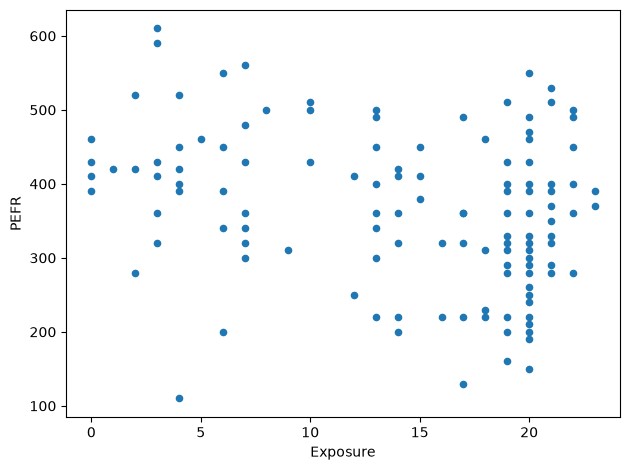

In [8]:
lung = pd.read_csv(LUNG_CSV)

lung.plot.scatter(x='Exposure', y='PEFR')

plt.tight_layout()
plt.show()

We can use the `LinearRegression` model from _scikit-learn_.

In [9]:
predictors = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


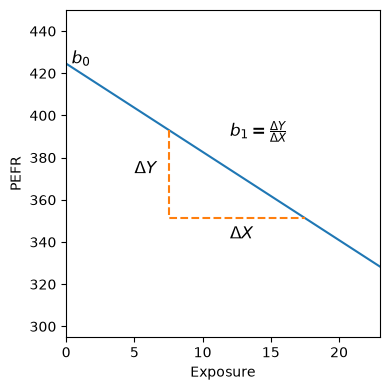

In [10]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 23)
ax.set_ylim(295, 450)
ax.set_xlabel('Exposure')
ax.set_ylabel('PEFR')
ax.plot((0, 23), model.predict(pd.DataFrame({'Exposure': [0, 23]})))
ax.text(0.4, model.intercept_, r'$b_0$', size='larger')

x = pd.DataFrame({'Exposure': [7.5,17.5]})
y = model.predict(x)
ax.plot((7.5, 7.5, 17.5), (y[0], y[1], y[1]), '--')
ax.text(5, np.mean(y), r'$\Delta Y$', size='larger')
ax.text(12, y[1] - 10, r'$\Delta X$', size='larger')
ax.text(12, 390, r'$b_1 = \frac{\Delta Y}{\Delta X}$', size='larger')

plt.tight_layout()
plt.show()

## Fitted Values and Residuals
The method `predict` of a fitted _scikit-learn_ model can be used to predict new data points.

In [11]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

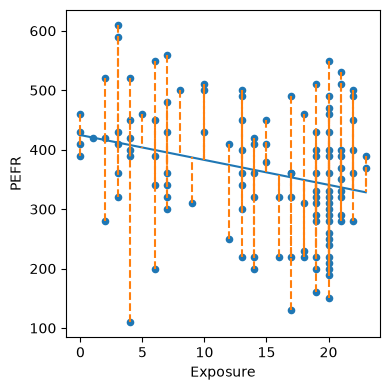

In [12]:
ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
ax.plot(lung.Exposure, fitted)
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted): 
    ax.plot((x, x), (yactual, yfitted), '--', color='C1')

plt.tight_layout()
plt.show()

# Multiple linear regression

In [13]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
          'Bedrooms', 'BldgGrade']

house = pd.read_csv(HOUSE_CSV, sep='\t')
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [14]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

print(f'Intercept: {house_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(predictors, house_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.83060360240754
 SqFtLot: -0.06046682065306008
 Bathrooms: -19442.840398321146
 Bedrooms: -47769.955185214094
 BldgGrade: 106106.9630789811


## Assessing the Model
_Scikit-learn_ provides a number of metrics to determine the quality of a model. Here we use the `r2_score`.

In [15]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 261220
r2: 0.5406


While _scikit-learn_ provides a variety of different metrics, _statsmodels_ provides a more in-depth analysis of the linear regression model. This package has two different ways of specifying the model, one that is similar to _scikit-learn_ and one that allows specifying _R_-style formulas. Here we use the first approach. As _statsmodels_ doesn't add an intercept automaticaly, we need to add a constant column with value 1 to the predictors. We can use the _pandas_ method assign for this.

In [16]:
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:15:29   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694

## Model Selection and Stepwise Regression

In [17]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]

house_full = sm.OLS(house[outcome], X.assign(const=1))
results = house_full.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:15:29   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving       

We can use the `stepwise_selection` method from the _dmba_ package.

In [18]:
y = house[outcome]
X_selection = X.sample(n=min(4000, len(X)), random_state=42) if MODE_CEPAT else X
y_selection = y.loc[X_selection.index]

def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(X_selection[variables], y_selection)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(y_selection, [y_selection.mean()] * len(y_selection), model, df=1)
    return AIC_score(y_selection, model.predict(X_selection[variables]), model)

best_model, best_variables = stepwise_selection(X.columns, train_model, score_model, 
                                                verbose=True)

print()
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant


Step: score=633013.35, add SqFtTotLiving


Step: score=630793.74, add BldgGrade


Step: score=628230.29, add YrBuilt


Step: score=627784.16, add Bedrooms


Step: score=627602.21, add Bathrooms


Step: score=627525.65, add PropertyType_Townhouse


Step: score=627525.08, add SqFtFinBasement


Step: score=627524.98, add PropertyType_Single Family


Step: score=627524.98, unchanged None

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420158
 BldgGrade: 137159.5602261976
 YrBuilt: -3565.424939249463
 Bedrooms: -51947.38367361413
 Bathrooms: 42396.16452772056
 PropertyType_Townhouse: 84479.16203299937
 SqFtFinBasement: 7.046974967583083
 PropertyType_Single Family: 22912.05518701767


## Weighted regression
We can calculate the Year from the date column using either a list comprehension or the data frame's `apply` method.

In [19]:
house['Year'] = [int(date.split('-')[0]) for date in house.DocumentDate]
house['Year'] = house.DocumentDate.apply(lambda d: int(d.split('-')[0]))
house['Weight'] = house.Year - 2005

In [20]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house.Weight)

pd.concat([
    pd.DataFrame({
        'predictor': predictors,
        'house_lm': house_lm.coef_,
        'house_wt': house_wt.coef_,    
    }),
    pd.DataFrame({
        'predictor': ['intercept'],
        'house_lm': house_lm.intercept_,
        'house_wt': house_wt.intercept_,    
    })
])

,predictor,house_lm,house_wt
0,SqFtTotLiving,228.830604,245.024089
1,SqFtLot,-0.060467,-0.292415
2,Bathrooms,-19442.840398,-26085.970109
3,Bedrooms,-47769.955185,-53608.876436
4,BldgGrade,106106.963079,115242.434726
0,intercept,-521871.368188,-584189.329446


In [21]:
residuals = pd.DataFrame({
    'abs_residual_lm': np.abs(house_lm.predict(house[predictors]) - house[outcome]),
    'abs_residual_wt': np.abs(house_wt.predict(house[predictors]) - house[outcome]),
    'Year': house['Year'],
})
print(residuals.head())
# axes = residuals.boxplot(['abs_residual_lm', 'abs_residual_wt'], by='Year', figsize=(10, 4))
# axes[0].set_ylim(0, 300000)

pd.DataFrame(([year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt'])] 
              for year, group in residuals.groupby('Year')),
             columns=['Year', 'mean abs_residual_lm', 'mean abs_residual_wt'])
# for year, group in residuals.groupby('Year'):
#     print(year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt']))

   abs_residual_lm  abs_residual_wt  Year
1    123750.814194    107108.553965  2014
2     59145.413089     96191.882094  2006
3    190108.725716    187004.492880  2007
4    198788.774412    196132.996857  2008
5     91774.996129     84277.577512  2013


,Year,mean abs_residual_lm,mean abs_residual_wt
0,2006,140540.303585,146557.454636
1,2007,147747.577959,152848.523235
2,2008,142086.905943,146360.411668
3,2009,147016.720883,151182.924825
4,2010,163267.674885,166364.476152
5,2011,169937.385744,172950.876028
6,2012,169506.670053,171874.424266
7,2013,203659.777510,206242.199403
8,2014,184452.840665,186668.573750
9,2015,172323.435147,169842.742053


# Factor variables in regression
## Dummy Variables Representation

In [22]:
print(house.PropertyType.head())

1        Multiplex
2    Single Family
3    Single Family
4    Single Family
5    Single Family
Name: PropertyType, dtype: str


In [23]:
print(pd.get_dummies(house['PropertyType']).head(6))

   Multiplex  Single Family  Townhouse
1       True          False      False
2      False           True      False
3      False           True      False
4      False           True      False
5      False           True      False
6      False          False       True


In [24]:
print(pd.get_dummies(house['PropertyType'], drop_first=True).head(6))

   Single Family  Townhouse
1          False      False
2           True      False
3           True      False
4           True      False
5           True      False
6          False       True


In [25]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType']

X = pd.get_dummies(house[predictors], drop_first=True)

house_lm_factor = LinearRegression()
house_lm_factor.fit(X, house[outcome])

print(f'Intercept: {house_lm_factor.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, house_lm_factor.coef_):
    print(f' {name}: {coef}')

Intercept: -446841.366
Coefficients:
 SqFtTotLiving: 223.37362892503805
 SqFtLot: -0.07036798136812195
 Bathrooms: -15979.013473415263
 Bedrooms: -50889.73218483014
 BldgGrade: 109416.30516146208
 PropertyType_Single Family: -84678.21629549275
 PropertyType_Townhouse: -115121.97921609186


## Factor Variables with many levels

In [26]:
print(pd.DataFrame(house['ZipCode'].value_counts()).transpose())

ZipCode  98038  98103  98042  98115  98117  98052  98034  98033  98059  98074  \
count      788    671    641    620    619    614    575    517    513    502   

ZipCode  ...  98051  98024  98354  98050  98057  98288  98224  98068  98113  \
count    ...     32     31      9      7      4      4      3      1      1   

ZipCode  98043  
count        1  

[1 rows x 80 columns]


In [27]:
house = pd.read_csv(HOUSE_CSV, sep='\t')

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])


zip_residuals = pd.DataFrame({
    'ZipCode': house['ZipCode'],
    'residual' : house[outcome] - house_lm.predict(house[predictors]),
})

zip_groups = pd.DataFrame([
    {
        'ZipCode': zipCode,
        'count': len(x),
        'median_residual': x.residual.median()
    } 
    for zipCode, x in zip_residuals.groupby('ZipCode')
]).sort_values('median_residual')

zip_groups['cum_count'] = np.cumsum(zip_groups['count'])
zip_groups['ZipGroup'] = pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=False)
zip_groups.head()
print(zip_groups.ZipGroup.value_counts().sort_index())

ZipGroup
0    16
1    16
2    16
3    16
4    16
Name: count, dtype: int64


In [28]:
to_join = zip_groups[['ZipCode', 'ZipGroup']].set_index('ZipCode')
house = house.join(to_join, on='ZipCode')
house['ZipGroup'] = house['ZipGroup'].astype('category')

# Interpreting the Regression Equation
## Correlated predictors

The results from the stepwise regression are.

In [29]:
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420158
 BldgGrade: 137159.5602261976
 YrBuilt: -3565.424939249463
 Bedrooms: -51947.38367361413
 Bathrooms: 42396.16452772056
 PropertyType_Townhouse: 84479.16203299937
 SqFtFinBasement: 7.046974967583083
 PropertyType_Single Family: 22912.05518701767


In [30]:
predictors = ['Bedrooms', 'BldgGrade', 'PropertyType', 'YrBuilt']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)

reduced_lm = LinearRegression()
reduced_lm.fit(X, house[outcome])


print(f'Intercept: {reduced_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, reduced_lm.coef_):
    print(f' {name}: {coef}')

Intercept: 4913973.344
Coefficients:
 Bedrooms: 27150.537230219703
 BldgGrade: 248997.79366212635
 YrBuilt: -3211.7448621551157
 PropertyType_Single Family: -19898.495340501973
 PropertyType_Townhouse: -47355.436873344275


## Confounding variables

In [31]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'ZipGroup']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)

confounding_lm = LinearRegression()
confounding_lm.fit(X, house[outcome])

print(f'Intercept: {confounding_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, confounding_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -666637.469
Coefficients:
 SqFtTotLiving: 210.61266005580134
 SqFtLot: 0.45498713854659023
 Bathrooms: 5928.425640001405
 Bedrooms: -41682.871840744636
 BldgGrade: 98541.18352726007
 PropertyType_Single Family: 19323.625287919374
 PropertyType_Townhouse: -78198.72092762377
 ZipGroup_1: 53317.17330659819
 ZipGroup_2: 116251.58883563553
 ZipGroup_3: 178360.5317879338
 ZipGroup_4: 338408.60185652046


## Interactions and Main Effects

In [32]:
model = smf.ols(formula='AdjSalePrice ~  SqFtTotLiving*ZipGroup + SqFtLot + ' +
     'Bathrooms + Bedrooms + BldgGrade + PropertyType', data=house)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3247.
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:15:32   Log-Likelihood:            -3.1098e+05
No. Observations:               22687   AIC:                         6.220e+05
Df Residuals:                   22671   BIC:                         6.221e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

> Results differ from R due to different binning. Enforcing the same binning gives identical results

# Testing the Assumptions: Regression Diagnostics
## Outliers

The _statsmodels_ package has the most developed support for outlier analysis. 

In [33]:
house_98105 = house.loc[house['ZipCode'] == 98105, ]

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade']
outcome = 'AdjSalePrice'

house_outlier = sm.OLS(house_98105[outcome], house_98105[predictors].assign(const=1))
result_98105 = house_outlier.fit()
print(result_98105.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          1.69e-103
Time:                        15:15:32   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   209.6023     24.408      8.587

The `OLSInfluence` class is initialized with the OLS regression results and gives access to a number of usefule properties. Here we use the studentized residuals. 

In [34]:
influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal

print(sresiduals.idxmin(), sresiduals.min())

24333 -4.3267318040785625


In [35]:
print(result_98105.resid.loc[sresiduals.idxmin()])

-757753.6192115827


In [36]:
outlier = house_98105.loc[sresiduals.idxmin(), :]
print('AdjSalePrice', outlier[outcome])
print(outlier[predictors])

AdjSalePrice 119748.0
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 24333, dtype: object


## Influential values

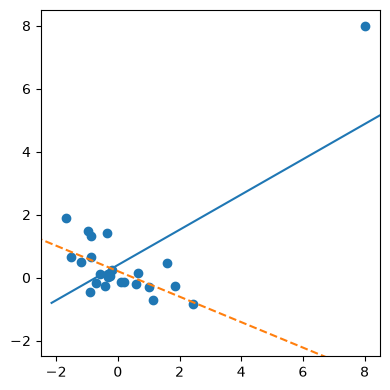

In [37]:
%matplotlib inline
from scipy.stats import linregress

np.random.seed(5)
x = np.random.normal(size=25)
y = -x / 5 + np.random.normal(size=25)
x[0] = 8
y[0] = 8

def abline(slope, intercept, ax):
    """Calculate coordinates of a line based on slope and intercept"""
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x, y)
slope, intercept, _, _, _ = linregress(x, y)
ax.plot(*abline(slope, intercept, ax))
slope, intercept, _, _, _ = linregress(x[1:], y[1:])
ax.plot(*abline(slope, intercept, ax), '--')
ax.set_xlim(-2.5, 8.5)
ax.set_ylim(-2.5, 8.5)

plt.tight_layout()
plt.show()

The package _statsmodel_ provides a number of plots to analyze the data point influence

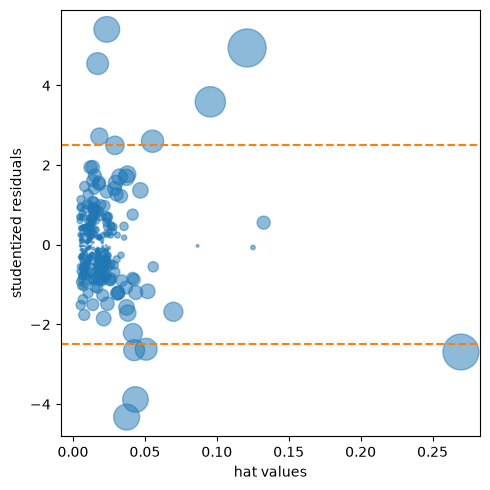

In [38]:
influence = OLSInfluence(result_98105)
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle='--', color='C1')
ax.axhline(2.5, linestyle='--', color='C1')
ax.scatter(influence.hat_matrix_diag, influence.resid_studentized_internal, 
           s=1000 * np.sqrt(influence.cooks_distance[0]),
           alpha=0.5)

ax.set_xlabel('hat values')
ax.set_ylabel('studentized residuals')

plt.tight_layout()
plt.show()

In [39]:
mask = [dist < .08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]

ols_infl = sm.OLS(house_infl[outcome], house_infl[predictors].assign(const=1))
result_infl = ols_infl.fit()

pd.DataFrame({
    'Original': result_98105.params,
    'Influential removed': result_infl.params,
})

,Original,Influential removed
SqFtTotLiving,209.602346,230.052569
SqFtLot,38.933315,33.141600
Bathrooms,2282.264145,-16131.879785
Bedrooms,-26320.268796,-22887.865318
BldgGrade,130000.099737,114870.559737
const,-772549.862447,-647137.096716


## Heteroskedasticity, Non-Normality and Correlated Errors

The `regplot` in _seaborn_ allows adding a lowess smoothing line to the scatterplot.

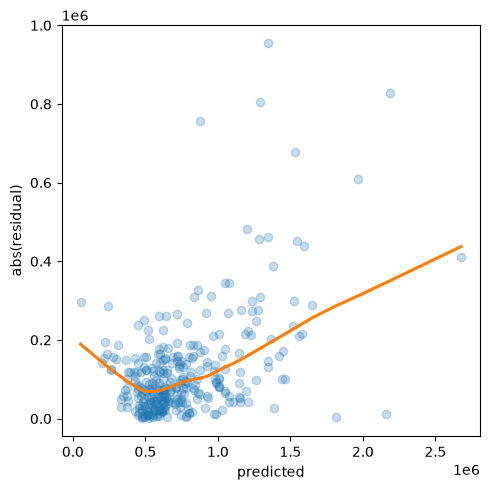

In [40]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid), 
            scatter_kws={'alpha': 0.25},
            line_kws={'color': 'C1'},
            lowess=True, ax=ax)
ax.set_xlabel('predicted')
ax.set_ylabel('abs(residual)')

plt.tight_layout()
plt.show()

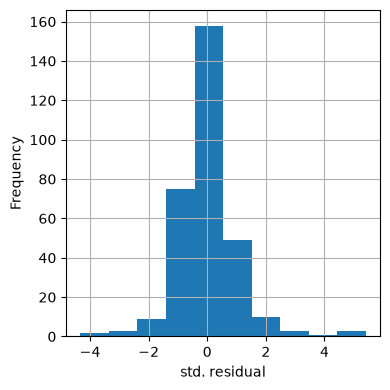

In [41]:
fig, ax = plt.subplots(figsize=(4, 4))
pd.Series(influence.resid_studentized_internal).hist(ax=ax)
ax.set_xlabel('std. residual')
ax.set_ylabel('Frequency')


plt.tight_layout()
plt.show()

## Partial Residual Plots and Nonlinearity

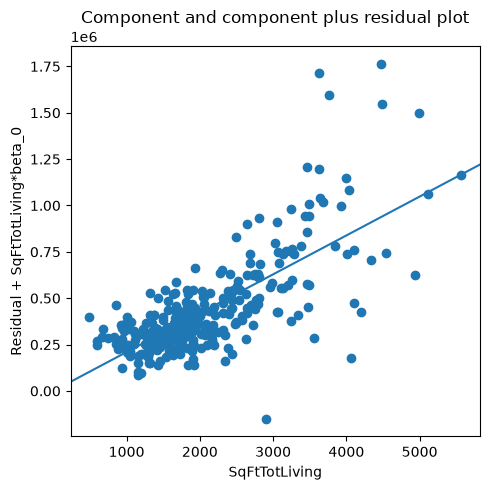

In [42]:
fig, ax = plt.subplots(figsize=(5, 5))
fig = sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=ax)

plt.tight_layout()
plt.show()

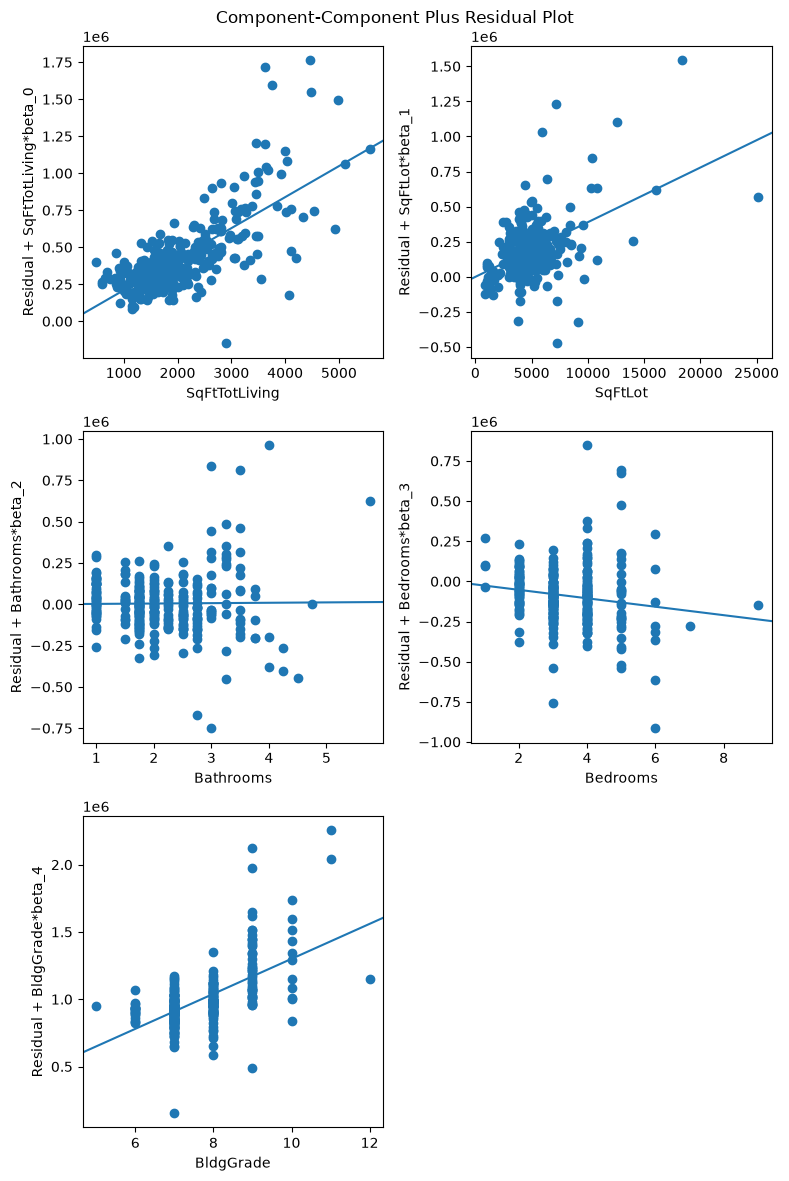

In [43]:
fig = plt.figure(figsize=(8, 12))
fig = sm.graphics.plot_ccpr_grid(result_98105, fig=fig)

## Polynomial and Spline Regression

In [44]:
model_poly = smf.ols(formula='AdjSalePrice ~  SqFtTotLiving + np.power(SqFtTotLiving, 2) + ' + 
                'SqFtLot + Bathrooms + Bedrooms + BldgGrade', data=house_98105)
result_poly = model_poly.fit()
print(result_poly.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          9.95e-106
Time:                        15:15:35   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The statsmodels implementation of a partial residual plot works only for linear term. Here is an implementation of a partial residual plot that, while inefficient, works for the polynomial regression.

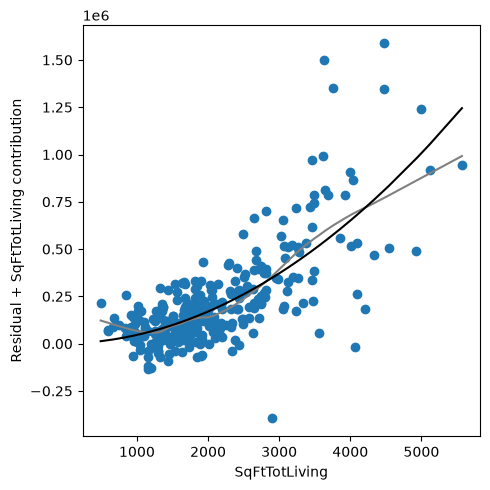

0.03879128168232195


In [45]:
def partialResidualPlot(model, df, outcome, feature, ax):
    y_pred = model.predict(df)
    # determine columns required for model
    required = set(model.params.index).intersection(df.columns)
    required.add(feature)
    copy_df = df[list(required)].copy().astype('float')
    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df.loc[:, c] = 0.0
    feature_prediction = model.predict(copy_df)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': df[outcome] - y_pred,
        'ypartial': feature_prediction - model.params.iloc[0],
    })
    results = results.sort_values(by=['feature'])
    smoothed = sm.nonparametric.lowess(results.ypartial + results.residual,
                                       results.feature, frac=1/3)
    
    ax.scatter(results.feature, results.ypartial + results.residual)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='gray')
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_poly, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()
print(result_poly.params.iloc[2])

## Splines

In [46]:
formula = ('AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + ' + 
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')
model_spline = smf.ols(formula=formula, data=house_98105)
result_spline = model_spline.fit()
print(result_spline.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     131.8
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          7.10e-104
Time:                        15:15:35   Log-Likelihood:                -4211.4
No. Observations:                 313   AIC:                             8445.
Df Residuals:                     302   BIC:                             8486.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


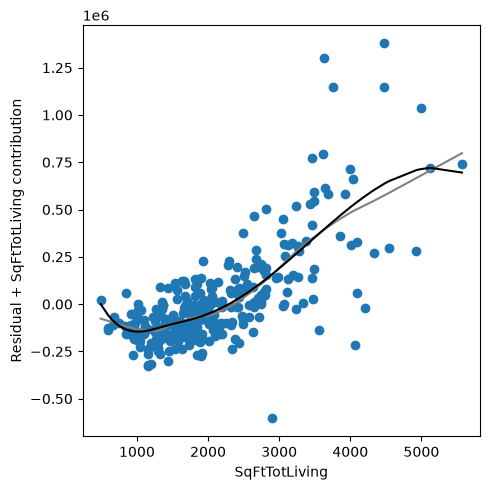

In [47]:
fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_spline, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()

## Generalized Additive Models

### Using statsmodels

In [48]:
from statsmodels.gam.api import GLMGam, BSplines

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

x_spline = house_98105[predictors]
bs = BSplines(x_spline, df=[10] + [3] * 4, degree=[3] + [2] * 4)
# penalization weight
alpha = np.array([0] * 5)

formula = ('AdjSalePrice ~ SqFtTotLiving + ' + 
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')

gam_sm = GLMGam.from_formula(formula, data=house_98105, smoother=bs, alpha=alpha)
res_sm = gam_sm.fit()
print(res_sm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           AdjSalePrice   No. Observations:                  313
Model:                         GLMGam   Df Residuals:                      295
Model Family:                Gaussian   Df Model:                        17.00
Link Function:               Identity   Scale:                      2.7471e+10
Method:                         PIRLS   Log-Likelihood:                -4196.6
Date:                Tue, 29 Sep 2026   Deviance:                   8.1039e+12
Time:                        15:15:36   Pearson chi2:                 8.10e+12
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9901
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -3.481e+05   1.18e+05  

D:\Kuliah\DL\.venv-statistics\Lib\site-packages\statsmodels\gam\generalized_additive_model.py:1223: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = lm.WLS(aug_y, aug_x, aug_weights).fit()
D:\Kuliah\DL\.venv-statistics\Lib\site-packages\statsmodels\gam\generalized_additive_model.py:1223: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = lm.WLS(aug_y, aug_x, aug_weights).fit()
D:\Kuliah\DL\.venv-statistics\Lib\site-packages\statsmodels\gam\generalized_additive_model.py:1223: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = lm.WLS(aug_y, aug_x, aug_weights).fit()


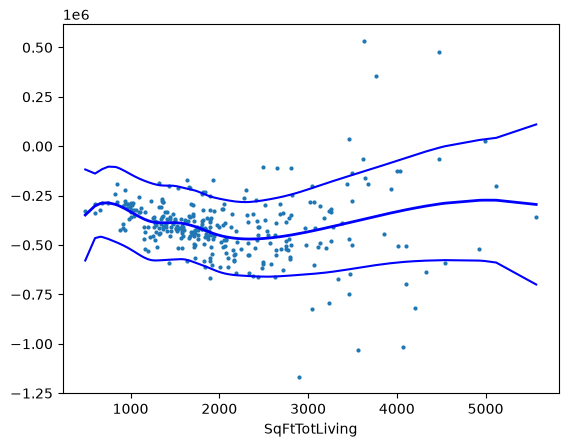

In [49]:
res_sm.plot_partial(0, cpr=True);

### Using pyGAM

In [50]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'
X = house_98105[predictors].values
y = house_98105[outcome]

## model
gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4))
gam.gridsearch(X, y, lam=([0.1, 1, 10] if MODE_CEPAT else np.logspace(-3, 3, 11)), progress=False)
print(gam.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6772
Link Function:                     IdentityLink Log Likelihood:                                 -4213.0332
Number of Samples:                          313 AIC:                                             8443.4209
                                                AICc:                                            8443.9746
                                                GCV:                                      30838885095.1709
                                                Scale:                                         171698.5198
                                                Pseudo R-Squared:                                   0.8117
Feature Function                  Lam

C:\Users\user\AppData\Local\Temp\ipykernel_10100\2724221202.py:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


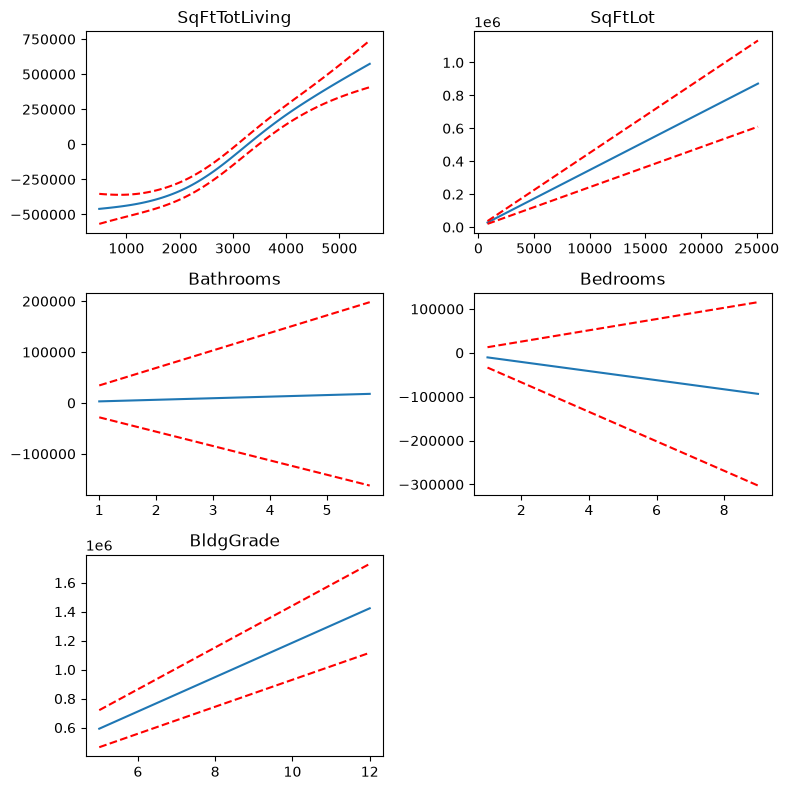

In [51]:
fig, axes = plt.subplots(figsize=(8, 8), ncols=2, nrows=3)

titles = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
for i, title in enumerate(titles):
    ax = axes[i // 2, i % 2]
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    ax.set_title(titles[i]);
    
axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()

# Additional material - not in book
# Regularization
## Lasso

In [52]:
from sklearn.linear_model import Lasso, LassoLars, LassoCV, LassoLarsCV
from sklearn.preprocessing import StandardScaler

In [53]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
          'Bedrooms', 'BldgGrade']

house = pd.read_csv(HOUSE_CSV, sep='\t')
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [54]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]
columns = X.columns
# X = StandardScaler().fit_transform(X * 1.0)
y = house[outcome]

house_lm = LinearRegression()
print(house_lm.fit(X, y))

LinearRegression()


In [55]:
house_lasso = Lasso(alpha=10)
print(house_lasso.fit(X, y))

Lasso(alpha=10)


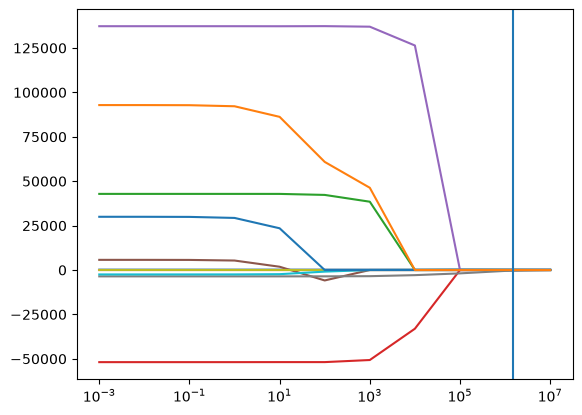

In [56]:
Method = LassoLars
MethodCV = LassoLarsCV
Method = Lasso
MethodCV = LassoCV

alpha_values = []
results = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]:
    model = Method(alpha=alpha)
    model.fit(X, y)
    alpha_values.append(alpha)
    results.append(model.coef_)
modelCV = MethodCV(cv=3, alphas=np.logspace(-2, 7, 20), n_jobs=2) if MODE_CEPAT else MethodCV(cv=5)
modelCV.fit(X, y)
ax = pd.DataFrame(results, index=alpha_values, columns=columns).plot(logx=True, legend=False)
ax.axvline(modelCV.alpha_)
plt.show()

In [57]:
pd.DataFrame({
    'name': columns,
    'coef': modelCV.coef_, 
})

,name,coef
0,SqFtTotLiving,289.048846
1,SqFtLot,0.029471
2,Bathrooms,0.000000
3,Bedrooms,0.000000
4,BldgGrade,0.000000
5,NbrLivingUnits,0.000000
6,SqFtFinBasement,3.316479
7,YrBuilt,-0.000000
8,YrRenovated,45.727472
9,NewConstruction,0.000000


In [58]:
# Intercept: 6177658.144
# Coefficients:
#  SqFtTotLiving: 199.27474217544048
#  BldgGrade: 137181.13724627026
#  YrBuilt: -3564.934870415041
#  Bedrooms: -51974.76845567939
#  Bathrooms: 42403.059999677665
#  PropertyType_Townhouse: 84378.9333363999
#  SqFtFinBasement: 7.032178917565108
#  PropertyType_Single Family: 22854.87954019308

# Eksperimen tambahan dan validasi
Sel berikut disusun sebagai pendalaman. Output muncul setelah sel kode dijalankan.

## Eksperimen tambahan: holdout, cross-validation, baseline, dan interval
Fitur asli numerik digunakan agar tidak memakai ZipGroup berbasis target. Test 20% disisihkan sebelum fitting; CV lima fold hanya memakai training. Split acak ini demonstrasi edukatif, bukan validasi temporal/spasial harga rumah.

In [59]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error,r2_score
import statsmodels.api as sm
DATA = next(p/'data' for p in [Path.cwd(), *Path.cwd().parents] if (p/'data'/'state.csv').exists())
h=pd.read_csv(DATA/'house_sales.csv',sep='\t')
features=['SqFtTotLiving','SqFtLot','Bathrooms','Bedrooms','BldgGrade']
Xtr,Xte,ytr,yte=train_test_split(h[features],h.AdjSalePrice,test_size=.2,random_state=42)
assert set(Xtr.index).isdisjoint(Xte.index)
rows=[]
for name,est in [('Baseline mean',DummyRegressor()),('Linear regression',LinearRegression())]:
    est.fit(Xtr,ytr); pred=est.predict(Xte)
    rows.append({'model':name,'RMSE_test':np.sqrt(mean_squared_error(yte,pred)),'R2_test':r2_score(yte,pred)})
display(pd.DataFrame(rows))
cv=-cross_val_score(LinearRegression(),Xtr,ytr,cv=KFold(5,shuffle=True,random_state=42),scoring='neg_root_mean_squared_error')
print('CV training RMSE mean:',cv.mean(),'; SD antarfold:',cv.std(ddof=1))
ols=sm.OLS(ytr,sm.add_constant(Xtr)).fit()
interval=ols.get_prediction(sm.add_constant(Xte,has_constant='add').iloc[:5]).summary_frame(alpha=.05)
display(interval)
assert ((interval.obs_ci_upper-interval.obs_ci_lower)>=(interval.mean_ci_upper-interval.mean_ci_lower)).all()

,model,RMSE_test,R2_test
0,Baseline mean,404572.105541,-0.000278
1,Linear regression,272593.821100,0.545890


CV training RMSE mean: 257775.92363706074 ; SD antarfold: 24704.15731259024


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
18056,5.778455e+05,9101.521738,5.600057e+05,5.956854e+05,71084.984173,1.084606e+06
7279,9.020268e+05,5463.909374,8.913170e+05,9.127365e+05,395467.097182,1.408586e+06
4225,5.503782e+05,3068.452771,5.443637e+05,5.563926e+05,43896.019362,1.056860e+06
12383,1.013855e+06,4994.791730,1.004065e+06,1.023645e+06,507313.959261,1.520396e+06
15951,2.055305e+05,3832.731884,1.980179e+05,2.130430e+05,-300971.692535,7.120326e+05


**Cara membaca:** bandingkan RMSE model dengan baseline pada test yang sama. SD skor CV adalah variasi antarfold, bukan confidence interval otomatis. Prediction interval lebih lebar karena memasukkan variasi individual; coverage tetap bergantung asumsi model.

## Ringkasan hasil yang diperoleh

Jalankan semua sel sebelumnya, kemudian sel berikut untuk menampilkan ringkasan dari hasil perhitungan saat ini.

In [60]:
# Metrik berasal dari holdout dan CV yang baru dijalankan.
display(pd.DataFrame(rows))
print(f'RMSE rata-rata CV training: {cv.mean():.2f}')
print('Bandingkan regresi dengan baseline pada test yang sama.')

,model,RMSE_test,R2_test
0,Baseline mean,404572.105541,-0.000278
1,Linear regression,272593.821100,0.545890


RMSE rata-rata CV training: 257775.92
Bandingkan regresi dengan baseline pada test yang sama.
